<a href="https://colab.research.google.com/github/yentran31251022363-ship-it/HW---Tran-Hai-Yen/blob/main/HW1_Tran_Hai_Yen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#23.1
import folium
from folium.plugins import MarkerCluster
UEH = [10.7756, 106.6920]
m = folium.Map(location=UEH, zoom_start=13)
folium.Marker(location=UEH,popup="UEH - Đại học Kinh tế TP.HCM").add_to(m)
# create
hospital= folium.FeatureGroup(name="Hospital")
bank = folium.FeatureGroup(name="Bank")
temple= folium.FeatureGroup(name="Temple")
park = folium.FeatureGroup(name="Park")
market = folium.FeatureGroup(name="Market")
#TẠO 5 ĐỊA ĐIỂM
folium.Marker([10.755654414084184, 106.66475199862401],popup="Bệnh viện Bình Dân").add_to(hospital)
folium.Marker([10.76048251180181, 106.66910446673383],popup="Vietcombank - PGD Nguyễn Tri Phương").add_to(bank)
folium.Marker([10.760958327896882, 106.67255297088299],popup="Chùa Giác Ngộ").add_to(temple)
folium.Marker([10.760568320273293, 106.67411938082184],popup="Công Viên Hòa Bình ").add_to(park)
folium.Marker([10.758375954918293, 106.67229547868311],popup="Chợ An Đông").add_to(market)
hospital.add_to(m)
temple.add_to(m)
bank.add_to(m)
park.add_to(m)
market.add_to(m)
folium.LayerControl().add_to(m)
m



In [10]:
  #23.2
  import folium
  import time
  from geopy.distance import geodesic
  from geopy.geocoders import Nominatim
  geolocator = Nominatim(user_agent="geoapi")
  ueh = geolocator.geocode("Đại học Kinh tế TP. Hồ Chí Minh (UEH) - Cơ sở B")
  center = ([10.761302994936663, 106.66831037023877])
  places = [
      "Nguyen Tri Phuong Hospital Ho Chi Minh City",
      "Hoa Hao Medic Hospital Ho Chi Minh City",
      "Vietcombank Nguyen Tri Phuong Ho Chi Minh City",
      "Bui Vien Walking Street Ho Chi Minh City",
      "Ben Thanh Market Ho Chi Minh City",
      "An Dong Market Ho Chi Minh City",
      "Le Thi Rieng Park Ho Chi Minh City",
      "Tao Dan Park Ho Chi Minh City ",
      "Bệnh viện Chợ Rẫy ",
      "Bệnh viện Đại học Y Dược TP.HCM"
  ]


  m = folium.Map(location=center, zoom_start=13)
  folium.Marker(center,popup="UEH").add_to(m)
  # xử lý từng địa điểm
  for place in places:
      try:
          loc = geolocator.geocode(place)
          time.sleep(1)
          point = (loc.latitude, loc.longitude)
          distance = geodesic(center, point).km
  # marker
          folium.Marker(point,popup=f"Distance: {distance:.2f} km").add_to(m)
  # line nối UEH
          folium.PolyLine( [center, point], color="purple").add_to(m)


      except:
          print("Error:", place)
m



In [11]:
#23.3
import folium, random
from folium.plugins import HeatMap
# Tọa độ của UEH Cơ sở B
center = [10.7615, 106.6672]
m = folium.Map(location=center, zoom_start=16)


# Giả lập dữ liệu tình trạng giao thông (các điểm xe đông/kẹt xe)
traffic_points = []
# 1. Vùng đỏ: Kẹt xe nghiêm trọng
for _ in range(60):
    lat = center[0] + random.uniform(-0.0015, 0.0015)
    lon = center[1] + random.uniform(-0.0015, 0.0015)
    traffic_points.append([lat, lon])


# 2. Vùng vàng: Xe đông, di chuyển chậm
for _ in range(30):
    lat = center[0] + random.uniform(-0.0035, 0.0035)
    lon = center[1] + random.uniform(-0.0035, 0.0035)
    traffic_points.append([lat, lon])


# 3. Vùng xanh: Giao thông thông thoáng
for _ in range(15):
    lat = center[0] + random.uniform(-0.006, 0.006)
    lon = center[1] + random.uniform(-0.006, 0.006)
    traffic_points.append([lat, lon])


HeatMap(traffic_points).add_to(m)
folium.Marker(center, popup="UEH Cơ sở B", icon=folium.Icon(color="red")).add_to(m)
m















In [12]:
#23.4
import folium
import pandas as pd


data_tanphu = pd.DataFrame({
    "Phuong": ["Tân Phú", "Phú Trung", "Hòa Thạnh", "Tân Thới Hòa"],
    "DanSo": [45000, 32000, 28000, 35000]
})


# Bảng dữ liệu cho Thủ Đức
data_thuduc = pd.DataFrame({
    "TenKhuVuc": ["Thành phố Thủ Đức"],
    "DanSo": [1200000]
})


center = [10.8200, 106.6800]
m = folium.Map(location=center, zoom_start=11)


folium.Choropleth(
    geo_data="/content/Tân Phú (phường xã) - 34.geojson",
    name="Tân Phú",
    data=data_tanphu,
    columns=["Phuong", "DanSo"],
    key_on="feature.properties.ten_xa",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name="Dân số Tân Phú (Phường)"
).add_to(m)


folium.Choropleth(
    geo_data="/content/ThuDucCity_boundary.json",
    name="Thủ Đức",
    data=data_thuduc,
    columns=["TenKhuVuc", "DanSo"],
    key_on="feature.properties.Ten",
    fill_color="PuBu",
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name="Dân số Thủ Đức"
).add_to(m)
folium.LayerControl().add_to(m)


m



FileNotFoundError: [Errno 2] No such file or directory: '/content/Tân Phú (phường xã) - 34.geojson'

In [13]:
#23.5
import folium
from geopy.distance import geodesic


# Tọa độ kho hàng
warehouse = (10.7756, 106.6920)


# Danh sách khách hàng
customers = [
    ("Khách 1", (10.7810, 106.6950)),  # Gần kho
    ("Khách 2", (10.7900, 106.7100)),  # Gần kho
    ("Khách 3", (10.7600, 106.6800)),  # Gần kho
    ("Khách 4", (10.7520, 106.6600)),  # Khoảng >3km, <5km
    ("Khách 5", (10.7700, 106.7000)),  # Gần kho
    ("Khách 6", (10.8200, 106.6300)),  # Xa hơn (Quận Tân Phú/Tân Bình) -> Khoảng >5km, <10km
    ("Khách 7", (10.8500, 106.5500))   # Rất xa (Hóc Môn/Bình Chánh) -> >10km
]




m = folium.Map(location=warehouse, zoom_start=13)
folium.Marker(warehouse, popup="<b>KHO HÀNG TRUNG TÂM</b>").add_to(m)
service_areas = [
    {"radius": 10000, "color": "orange", "label": "10 km"},
    {"radius": 5000, "color": "blue", "label": "5 km"},
    {"radius": 3000, "color": "green", "label": "3 km"}
]


for area in service_areas:
    folium.Circle(
        location=warehouse,
        radius=area["radius"],
        color=area["color"],
        fill=True,
        fill_opacity=0.1,
        popup=f"Vùng phục vụ {area['label']}"
    ).add_to(m)


for name, location in customers:
    distance = geodesic(warehouse, location).km
    if distance <= 3:
        color = "green"
        status = "Thuộc vùng lõi (3 km)"
    elif distance <= 5:
        color = "blue"
        status = "Thuộc vùng mở rộng (5 km)"
    elif distance <= 10:
        color = "orange"
        status = "Thuộc vùng viền (10 km)"
    else:
        color = "red"
        status = "Ngoài phạm vi phục vụ (>10 km)"

    popup_content = f"<b>{name}</b><br>Khoảng cách: {distance:.1f} km<br>Trạng thái: {status}"
    folium.Marker(
        location,
        popup=popup_content,
        icon=folium.Icon(color=color)
    ).add_to(m)
m
#Đề xuất: Phạm vi hoạt động tối ưu nhất nên tập trung marketing và phân phối ở bán kính 5 km đổ lại để đảm bảo biên độ lợi nhuận và chất lượng dịch vụ.



  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.4 MB/s eta 0:00:00
  Created wheel for network: filename=network-0.1-py3-none-any.whl size=3138 sha256=4491ec10f21f9087b1f3d1d71eb57249fcda75a63b4235aaddb8771872fec8b9
  Stored in directory: /root/.cache/pip/wheels/e7/5a/7a/7f15bea66afb5505b9d10cc7bd8964cb77f0ce736df5b104c8
Successfully built network
Place: District 4, Ho Chi Minh City, Vietnam
Nodes: 412
Edges: 918
Average length (m): 83.87
Density: 211.94


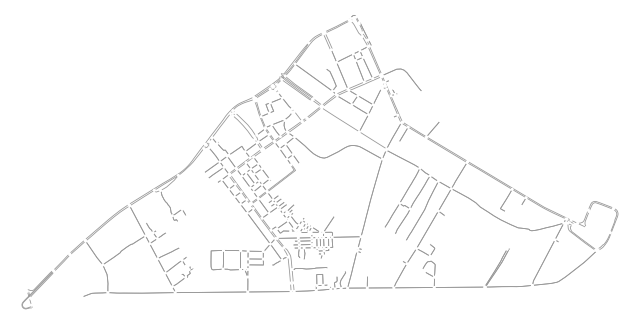

In [15]:
#23.6
!pip install folium geopy osmnx network
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
place = "District 4, Ho Chi Minh City, Vietnam"


G = ox.graph_from_place(place, network_type="drive")


nodes = len(G.nodes)
edges = len(G.edges)


lengths = [data["length"] for u, v, k, data in G.edges(keys=True, data=True)]
avg_length = sum(lengths) / len(lengths)


area = ox.geocode_to_gdf(place).to_crs(epsg=3857).area.iloc[0] / 1000000


density = edges / area


print("Place:", place)
print("Nodes:", nodes)
print("Edges:", edges)
print("Average length (m):", round(avg_length, 2))
print("Density:", round(density, 2))


fig, ax = ox.plot_graph(G, node_size=5, edge_linewidth=0.6, bgcolor="white", show=False, close=False)
plt.show()



In [16]:
#23.7
import osmnx as ox
import networkx as nx
import folium


place = "District 4, Ho Chi Minh City, Vietnam"


G_raw = ox.graph_from_place(place, network_type="drive")




G = ox.truncate.largest_component(G_raw, strongly=True)
start_point = (10.7675, 106.7005)
end_point = (10.7550, 106.7160)


# Tìm các nút giao gần nhất
start_node = ox.distance.nearest_nodes(G, start_point[1], start_point[0])
end_node = ox.distance.nearest_nodes(G, end_point[1], end_point[0])


try:
    # Chạy thuật toán Dijkstra
    route_dijkstra = nx.shortest_path(G, start_node, end_node, weight="length", method="dijkstra")

    # Chạy thuật toán A*
    def heuristic(u, v):
        node_u = G.nodes[u]
        node_v = G.nodes[v]
        return ((node_u['y'] - node_v['y'])**2 + (node_u['x'] - node_v['x'])**2)**0.5

    route_astar = nx.astar_path(G, start_node, end_node, heuristic=heuristic, weight="length")


    # In kết quả
    print("Dijkstra distance (m):", round(nx.path_weight(G, route_dijkstra, weight="length"), 2))
    print("A Star distance (m):", round(nx.path_weight(G, route_astar, weight="length"), 2))


    # Vẽ bản đồ
    m = folium.Map(location=start_point, zoom_start=15)
    folium.Marker(start_point, popup="Start", icon=folium.Icon(color="green")).add_to(m)
    folium.Marker(end_point, popup="End", icon=folium.Icon(color="red")).add_to(m)

    coords = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in route_dijkstra]
    folium.PolyLine(coords, color="blue", weight=5).add_to(m)

    display(m)


except nx.NetworkXNoPath:
    print("Lỗi: Vẫn không tìm thấy đường đi giữa hai điểm này. Hãy thử chọn tọa độ khác!")



Dijkstra distance (m): 2270.92
A Star distance (m): 2270.92


In [17]:
#23.8
import folium
import random
from geopy.distance import geodesic


center = (10.7756, 106.6920)
num_cars = 6
num_customers = 5


cars = [(center[0] + random.uniform(-0.02, 0.02), center[1] + random.uniform(-0.02, 0.02)) for _ in range(num_cars)]
customers = [(center[0] + random.uniform(-0.02, 0.02), center[1] + random.uniform(-0.02, 0.02)) for _ in range(num_customers)]


used_cars = set()
m = folium.Map(location=center, zoom_start=14)


for i, car_pos in enumerate(cars):
    folium.Marker(
        location=car_pos,
        popup=f"Car {i+1}",
        icon=folium.Icon(color="blue", icon="car", prefix="fa")
    ).add_to(m)


for i, cust_pos in enumerate(customers):
    available_cars = [(j, geodesic(cust_pos, cars[j]).km) for j in range(len(cars)) if j not in used_cars]

    if not available_cars:
        print(f"Hết xe cho khách hàng {i+1}")
        continue


    # Chọn xe có khoảng cách nhỏ nhất
    best_car_idx, dist = min(available_cars, key=lambda x: x[1])
    used_cars.add(best_car_idx)


    folium.Marker(
        location=cust_pos,
        popup=f"Customer {i+1} (Dist: {dist:.2f}km)",
        icon=folium.Icon(color="red", icon="user", prefix="fa")
    ).add_to(m)


    folium.PolyLine(
        locations=[cars[best_car_idx], cust_pos],
        color="green",
        weight=4,
        opacity=0.7,
        tooltip=f"Car {best_car_idx+1} -> Customer {i+1}"
    ).add_to(m)


m



In [18]:
#23.9
import folium
import random
import pandas as pd
from sklearn.cluster import KMeans
center=(10.7675, 106.7005)
points=[(10.7675+random.uniform(-0.03,0.03),106.7005+random.uniform(-0.03,0.03)) for i in range(30)]
df=pd.DataFrame(points,columns=["lat","lon"])
model=KMeans(n_clusters=3,random_state=42)
df["cluster"]=model.fit_predict(df[["lat","lon"]])
centers=model.cluster_centers_
colors=["red","blue","green"]
m=folium.Map(location=center,zoom_start=13)
for i in range(len(df)):
    c=df.loc[i,"cluster"]
    folium.CircleMarker(location=(df.loc[i,"lat"],df.loc[i,"lon"]),radius=5,color=colors[c],fill=True,fill_opacity=0.8,popup="Cluster "+str(c+1)).add_to(m)
for i in range(3):
    folium.Marker(location=(centers[i][0],centers[i][1]),popup="Hub "+str(i+1),icon=folium.Icon(color="purple")).add_to(m)
m







In [22]:
#23.11
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


# 1. Tạo dữ liệu giả lập
np.random.seed(42)
data = {
    'hour': np.random.randint(0, 24, 1000),
    'day_of_week': np.random.randint(0, 7, 1000),
    'lat': np.random.uniform(10.75, 10.82, 1000),
    'lon': np.random.uniform(106.63, 106.72, 1000),
}
df = pd.DataFrame(data)


# Giả lập nhu cầu:
df['demand'] = (
    (df['hour'].isin([8, 9, 17, 18, 19])).astype(int) * 20 +
    np.random.randint(5, 15, 1000)
)


X = df[['hour', 'day_of_week', 'lat', 'lon']]
y = df['demand']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)


# 3. Dự báo cho một khung giờ cụ thể
predict_hour = 18
predict_day = 4
predict_points = 500
lats = np.random.uniform(10.75, 10.82, predict_points)
lons = np.random.uniform(106.63, 106.72, predict_points)
grid = [[predict_hour, predict_day, lat, lon] for lat, lon in zip(lats, lons)]
predictions = model.predict(grid)


m = folium.Map(location=[10.7756, 106.6920], zoom_start=13)


heat_data = [[grid[i][2], grid[i][3], predictions[i]] for i in range(len(grid))]


HeatMap(heat_data, radius=25, blur=15, gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}).add_to(m)
title_html = f'''<h3 align="center" style="font-size:16px"><b>Bản đồ dự báo nhu cầu dịch vụ lúc {predict_hour}:00</b></h3>'''
m.get_root().html.add_child(folium.Element(title_html))
m



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [23]:
#23.12
import folium
import numpy as np
from geopy.distance import geodesic

depots = {
    'Kho A': (10.7626, 106.6602),
    'Kho B': (10.7961, 106.6737)
}

customers = [
    (10.7736, 106.6944), (10.7850, 106.7020), (10.7580, 106.6750),
    (10.8120, 106.6450), (10.7420, 106.7200), (10.8000, 106.6300)
]

# 2. Thuật toán Heuristic
def optimize_route(start_node, pending_customers):
    route = [start_node]
    current_pos = start_node
    total_dist = 0

    while pending_customers:
        next_node = min(pending_customers, key=lambda x: geodesic(current_pos, x).km)
        total_dist += geodesic(current_pos, next_node).km
        route.append(next_node)
        current_pos = next_node
        pending_customers.remove(next_node)

    return route, total_dist

m = folium.Map(location=[10.7769, 106.6850], zoom_start=13)

# Chia khách hàng làm 2 nhóm cho 2 xe
cust_group_A = customers[:3]
cust_group_B = customers[3:]

results = []
colors = ['blue', 'red']

for i, (name, pos) in enumerate(depots.items()):
    pending = cust_group_A if name == 'Kho A' else cust_group_B

    # Tính phương án KHÔNG tối ưu
    dist_start = geodesic(pos, pending[0]).km
    dist_between = sum(geodesic(pending[j], pending[j+1]).km for j in range(len(pending)-1))
    dist_non_opt = dist_start + dist_between

    # Tính phương án TỐI ƯU (Heuristic)
    route, dist_opt = optimize_route(pos, pending.copy())
    results.append((name, dist_non_opt, dist_opt))

    folium.Marker(pos, popup=name, icon=folium.Icon(color=colors[i], icon='home')).add_to(m)
    folium.PolyLine(route, color=colors[i], weight=5, opacity=0.7, popup=f"Tuyến {name}").add_to(m)
    for c_pos in pending:
        folium.CircleMarker(c_pos, radius=5, color=colors[i], fill=True).add_to(m)

print(f"{'Kho':<10} | {'Chưa tối ưu (km)':<20} | {'Tối ưu (km)':<15} | {'Tiết kiệm'}")
print("-" * 65)
for res in results:
    saving = (1 - res[2]/res[1]) * 100
    print(f"{res[0]:<10} | {res[1]:<20.2f} | {res[2]:<15.2f} | {saving:.1f}%")

m

Kho        | Chưa tối ưu (km)     | Tối ưu (km)     | Tiết kiệm
-----------------------------------------------------------------
Kho A      | 9.64                 | 5.94            | 38.4%
Kho B      | 26.63                | 17.46           | 34.4%


In [26]:
#23.15
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

# 1. Giả lập dữ liệu dân cư
np.random.seed(10)
lats = np.random.uniform(10.75, 10.82, 500)
lons = np.random.uniform(106.63, 106.72, 500)
res_df = pd.DataFrame({'lat': lats, 'lon': lons})

competitors = [
    [10.7750, 106.6950], [10.7800, 106.6800],
    [10.7600, 106.6600], [10.7900, 106.7000]
]

db = DBSCAN(eps=0.005, min_samples=15).fit(res_df[['lat', 'lon']])
res_df['cluster'] = db.labels_

clusters = res_df[res_df['cluster'] != -1].groupby('cluster')[['lat', 'lon']].mean()

m = folium.Map(location=[10.7756, 106.6920], zoom_start=13, tiles="CartoDB dark_matter")

# Vẽ các cụm dân cư tiềm năng (Màu vàng - Vùng nên khai thác)
for _, row in clusters.iterrows():
    folium.Circle(
        location=[row['lat'], row['lon']],
        radius=600,
        color='yellow',
        fill=True,
        fill_opacity=0.3,
        popup='Vùng tiềm năng (Mật độ dân cư cao)'
    ).add_to(m)

# Vẽ vị trí đối thủ (Màu đỏ - Vùng nên tránh)
for cp in competitors:
    folium.Marker(
        location=cp,
        icon=folium.Icon(color='red', icon='times', prefix='fa'),
        popup='Đối thủ cạnh tranh'
    ).add_to(m)

# ĐỀ XUẤT CỦA AI: Vị trí mở cửa hàng tối ưu (Điểm tiềm năng nhưng xa đối thủ)
# Ở đây ta chọn một tọa độ mẫu đại diện cho kết quả phân tích
folium.Marker(
    location=[10.8100, 106.6500],
    icon=folium.Icon(color='green', icon='star', prefix='fa'),
    popup='<b>ĐỀ XUẤT: VỊ TRÍ MỞ CỬA HÀNG LÝ TƯỞNG</b>'
).add_to(m)

m